<div style="padding:24px;border-left:8px solid #C99700;background:#071B33;color:white;border-radius:8px">
<h1 style="margin:0">Lab 03 · Portfolio Optimization Under Estimation Error</h1>
<p style="font-size:17px;margin-bottom:0">The optimizer is treated as an error amplifier, not an oracle.</p>
</div>

**Research question.** How stable are minimum-variance factor allocations when covariance matrices are estimated from finite samples, and do robust constraints survive a walk-forward test after costs?

**Evidence.** Monthly Fama–French five-factor and momentum research returns saved by the factor-allocation project. Factor portfolios are research constructs, not frictionless directly investable assets.

## 1. The inverse-covariance problem

The fully invested global minimum-variance portfolio is

$$w^*=\frac{\Sigma^{-1}\mathbf 1}{\mathbf 1^\top\Sigma^{-1}\mathbf 1}.$$

If $\widehat\Sigma$ has a small eigenvalue, inversion magnifies its estimation error. A diagonal shrinkage estimator

$$\widehat\Sigma_\alpha=(1-\alpha)\widehat\Sigma+\alpha\operatorname{diag}(\widehat\Sigma)$$

adds bias deliberately to reduce variance and improve conditioning. This is a statistical regularization decision, not a theorem that 50% shrinkage is universally optimal.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_root():
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate/'projects'/'factor_allocation'/'output'/'monthly_factors.csv').exists():
            return candidate
    raise FileNotFoundError('Run projects/factor_allocation/run_research.py first')

ROOT = find_root(); OUT = ROOT/'projects'/'factor_allocation'/'output'
sys.path.insert(0, str(ROOT))
from utils.quant_models import diagonal_covariance_shrinkage, performance_summary

FACTORS = ['Mkt-RF','SMB','HML','RMW','CMA','Mom']
factors = pd.read_csv(OUT/'monthly_factors.csv', index_col='date', parse_dates=True)
walk = pd.read_csv(OUT/'walk_forward_allocation.csv', index_col='date', parse_dates=True)
plt.style.use('seaborn-v0_8-whitegrid')
NAVY, BLUE, GOLD, RED, GREEN = '#071B33', '#1676B8', '#C99700', '#C84C4C', '#26866A'
pd.options.display.float_format = '{:,.4f}'.format
print((OUT/'provenance.txt').read_text())
display(pd.DataFrame({c: performance_summary(factors[c], periods_per_year=12) for c in FACTORS}).T)

Source: Kenneth R. French Data Library monthly research factors
Five-factor URL: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip
Momentum URL: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Momentum_Factor_CSV.zip
Rows: 756
First month: 1963-07-31 00:00:00
Last month: 2026-06-30 00:00:00
Generated UTC: 2026-08-28T00:53:40.902988+00:00
Input percentage returns are converted to decimal returns.
French-library methodology and CRSP input format can change over time.
Factor portfolios are research returns, not costless directly traded assets.
Allocation charges 10 bps per unit of one-way turnover.
Synthetic fallback validates software only and cannot support market claims.



,observations,annualized_geometric_return,annualized_volatility,sharpe_ratio,max_drawdown,period_VaR_95_loss,period_ES_95_loss,period_VaR_99_loss,period_ES_99_loss,skewness,excess_kurtosis
Mkt-RF,756.0000,0.0617,0.1546,0.3990,-0.5575,0.0721,0.1002,0.1135,0.1489,-0.4919,1.7250
SMB,756.0000,0.0171,0.1047,0.1630,-0.5647,0.0432,0.0586,0.0683,0.0874,0.3584,3.0595
HML,756.0000,0.0310,0.1028,0.3012,-0.5779,0.0410,0.0619,0.0782,0.0970,0.0907,2.1772
RMW,756.0000,0.0259,0.0781,0.3324,-0.4178,0.0290,0.0485,0.0547,0.0898,-0.3805,10.5741
CMA,756.0000,0.0272,0.0718,0.3795,-0.2721,0.0277,0.0401,0.0494,0.0618,0.2684,1.3404
Mom,756.0000,0.0654,0.1446,0.4525,-0.5785,0.0651,0.1021,0.1173,0.1789,-1.3010,9.7879


## 2. Diversification structure and numerical conditioning

Correlation describes standardized co-movement; optimization uses covariance and is sensitive to scale. The spectral condition number $\kappa(\Sigma)=\lambda_{max}/\lambda_{min}$ measures how strongly inversion can magnify perturbations.

,condition_number,smallest_eigenvalue,largest_eigenvalue
sample,10.8453,0.0003,0.0028
50% diagonal shrinkage,4.7488,0.0005,0.0023


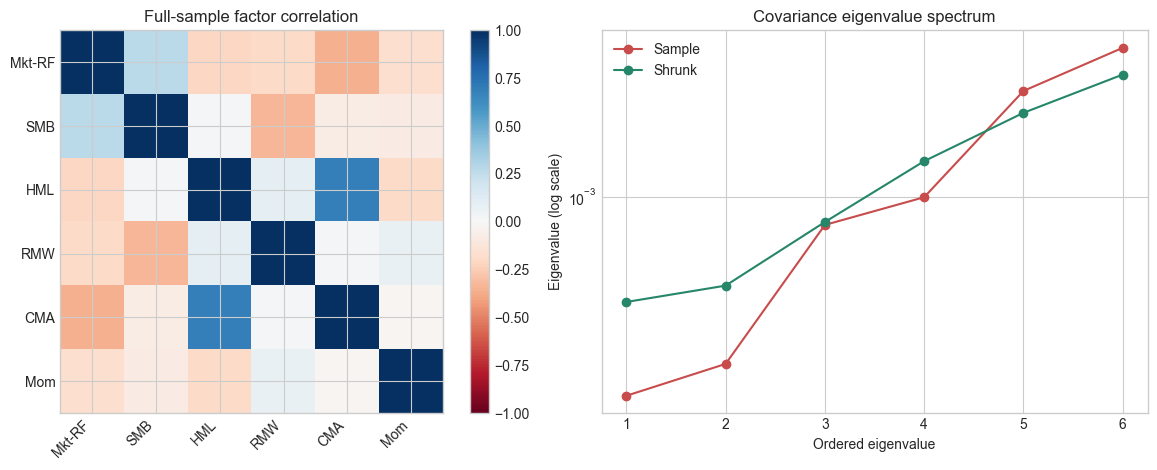

In [2]:
window = factors[FACTORS].iloc[-120:]
sample_cov = window.cov()
shrunk_cov = diagonal_covariance_shrinkage(window, intensity=.50)
spectral = pd.DataFrame({
    'sample': np.linalg.eigvalsh(sample_cov),
    '50% diagonal shrinkage': np.linalg.eigvalsh(shrunk_cov)
})
condition = spectral.max()/spectral.min()
display(pd.DataFrame({'condition_number':condition,
                      'smallest_eigenvalue':spectral.min(),
                      'largest_eigenvalue':spectral.max()}))

corr = factors[FACTORS].corr()
fig, axes = plt.subplots(1,2,figsize=(12.5,4.8))
im = axes[0].imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(FACTORS)), FACTORS, rotation=45, ha='right')
axes[0].set_yticks(range(len(FACTORS)), FACTORS)
axes[0].set_title('Full-sample factor correlation')
fig.colorbar(im, ax=axes[0], fraction=.046)
axes[1].semilogy(range(1,7), spectral['sample'].sort_values(), 'o-', label='Sample', color=RED)
axes[1].semilogy(range(1,7), spectral['50% diagonal shrinkage'].sort_values(), 'o-', label='Shrunk', color=GREEN)
axes[1].set(title='Covariance eigenvalue spectrum', xlabel='Ordered eigenvalue', ylabel='Eigenvalue (log scale)')
axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

## 3. Bootstrap the optimizer, not just the returns

A point estimate of weights hides parameter risk. We resample the same 120-month training window and recompute unconstrained GMV weights. Weight dispersion is the sampling distribution induced by the portfolio construction rule.

,sample_weight_sd,shrunk_weight_sd,sample_negative_frequency,shrunk_negative_frequency
Mkt-RF,0.0286,0.0172,0.0050,0.0000
SMB,0.0437,0.0289,0.0000,0.0000
HML,0.0441,0.0166,0.8350,0.0000
RMW,0.0494,0.0412,0.0000,0.0000
CMA,0.0555,0.0319,0.0050,0.0000
Mom,0.0314,0.0263,0.0000,0.0000


C:\Users\badre\AppData\Local\Temp\ipykernel_33840\4149576577.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([sample_weights[c] for c in FACTORS], labels=FACTORS, showfliers=False)
C:\Users\badre\AppData\Local\Temp\ipykernel_33840\4149576577.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([shrunk_weights[c] for c in FACTORS], labels=FACTORS, showfliers=False)


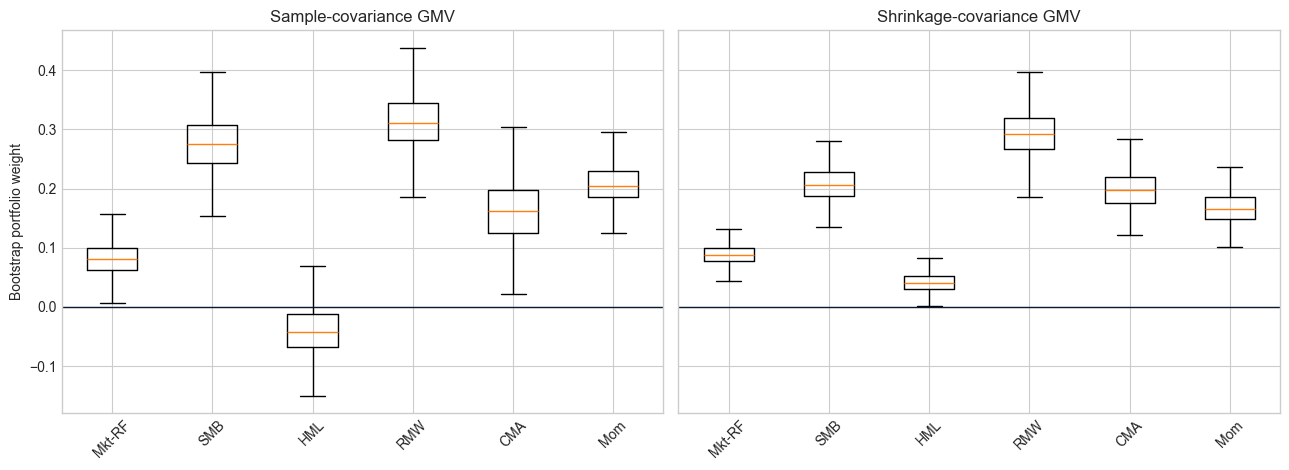

In [3]:
def gmv(covariance):
    precision_one = np.linalg.solve(covariance, np.ones(covariance.shape[0]))
    return precision_one/precision_one.sum()

rng = np.random.default_rng(20260828)
sample_weights, shrunk_weights = [], []
for _ in range(800):
    idx = rng.integers(0, len(window), len(window))
    boot = window.iloc[idx]
    sample_weights.append(gmv(boot.cov().to_numpy()))
    shrunk_weights.append(gmv(diagonal_covariance_shrinkage(boot,.50).to_numpy()))
sample_weights = pd.DataFrame(sample_weights, columns=FACTORS)
shrunk_weights = pd.DataFrame(shrunk_weights, columns=FACTORS)
stability = pd.DataFrame({
    'sample_weight_sd': sample_weights.std(),
    'shrunk_weight_sd': shrunk_weights.std(),
    'sample_negative_frequency': (sample_weights<0).mean(),
    'shrunk_negative_frequency': (shrunk_weights<0).mean(),
})
display(stability)

fig, axes = plt.subplots(1,2,figsize=(13,4.8), sharey=True)
axes[0].boxplot([sample_weights[c] for c in FACTORS], labels=FACTORS, showfliers=False)
axes[1].boxplot([shrunk_weights[c] for c in FACTORS], labels=FACTORS, showfliers=False)
for ax, title in zip(axes, ['Sample-covariance GMV','Shrinkage-covariance GMV']):
    ax.axhline(0,color=NAVY,linewidth=1); ax.set_title(title); ax.tick_params(axis='x',rotation=45)
axes[0].set_ylabel('Bootstrap portfolio weight')
plt.tight_layout(); plt.show()

## 4. Walk-forward evidence

The project strategy uses a trailing 120-month covariance matrix, 50% diagonal shrinkage, long-only weights, a 40% sleeve cap, and 10 basis points per unit of one-way turnover. No return at month $t$ enters the weights held during month $t$.

The benchmark is equal weight. It is intentionally simple, diversified, and nearly free of estimation error.

,observations,annualized_geometric_return,annualized_volatility,sharpe_ratio,max_drawdown,period_VaR_95_loss,period_ES_95_loss,period_VaR_99_loss,period_ES_99_loss,skewness,excess_kurtosis,average_monthly_turnover
Robust GMV gross,636.0000,0.0321,0.0360,0.8916,-0.1170,0.0132,0.0218,0.0267,0.0328,0.0097,2.9545,0.0065
Robust GMV net,636.0000,0.0320,0.0360,0.8893,-0.1172,0.0132,0.0218,0.0268,0.0328,0.0085,2.9515,0.0065
Equal weight,636.0000,0.0447,0.0414,1.0792,-0.1237,0.0143,0.0257,0.0291,0.0452,-0.4078,4.1947,0.0000


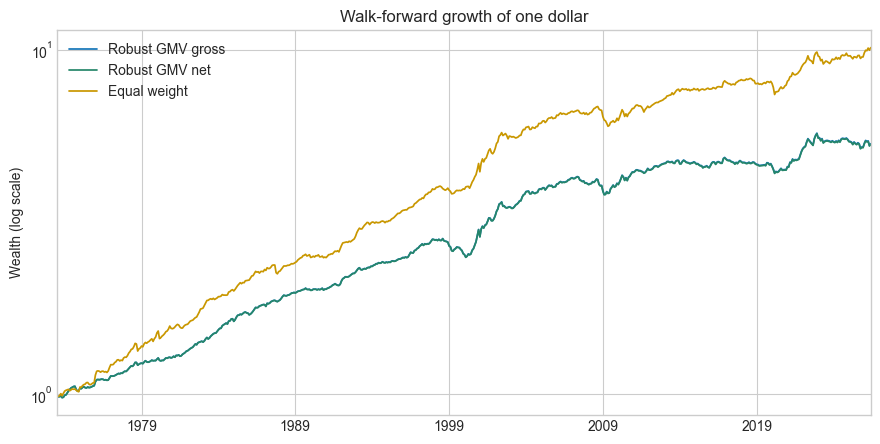

In [4]:
equal = factors.loc[walk.index, FACTORS].mean(axis=1)
comparison = pd.DataFrame({
    'Robust GMV gross': walk.gross_return,
    'Robust GMV net': walk.net_return,
    'Equal weight': equal
}).dropna()
summary = pd.DataFrame({c: performance_summary(comparison[c], periods_per_year=12)
                        for c in comparison}).T
summary['average_monthly_turnover'] = [walk.turnover.mean(),walk.turnover.mean(),0]
display(summary)

wealth = (1+comparison).cumprod()
ax = wealth.plot(figsize=(10.5,5), logy=True, color=[BLUE,GREEN,GOLD], linewidth=1.25)
ax.set(title='Walk-forward growth of one dollar', ylabel='Wealth (log scale)', xlabel='')
plt.show()

## 5. Frictions and the look-ahead impossibility benchmark

Cost sensitivity asks whether the conclusion survives plausible implementation assumptions. The “oracle” chooses each month’s best factor after observing that same month. It is impossible to trade and is included as a leakage detector: a realistic backtest that resembles it deserves immediate scrutiny.

,annualized_geometric_return,annualized_volatility,sharpe_ratio,max_drawdown
cost_bps,,,,
0,0.0321,0.0360,0.8916,-0.1170
5,0.0321,0.0360,0.8905,-0.1171
10,0.0320,0.0360,0.8893,-0.1172
25,0.0319,0.0360,0.8859,-0.1174
50,0.0317,0.0360,0.8801,-0.1178


,observations,annualized_geometric_return,annualized_volatility,sharpe_ratio,max_drawdown,period_VaR_95_loss,period_ES_95_loss,period_VaR_99_loss,period_ES_99_loss,skewness,excess_kurtosis
Valid robust GMV,636.0000,0.0320,0.0360,0.8893,-0.1172,0.0132,0.0218,0.0268,0.0328,0.0085,2.9515
Valid equal weight,636.0000,0.0447,0.0414,1.0792,-0.1237,0.0143,0.0257,0.0291,0.0452,-0.4078,4.1947
Impossible same-month oracle,636.0000,0.6454,0.0916,7.0444,-0.0010,-0.0111,-0.0070,-0.0049,-0.0018,1.4901,3.5039


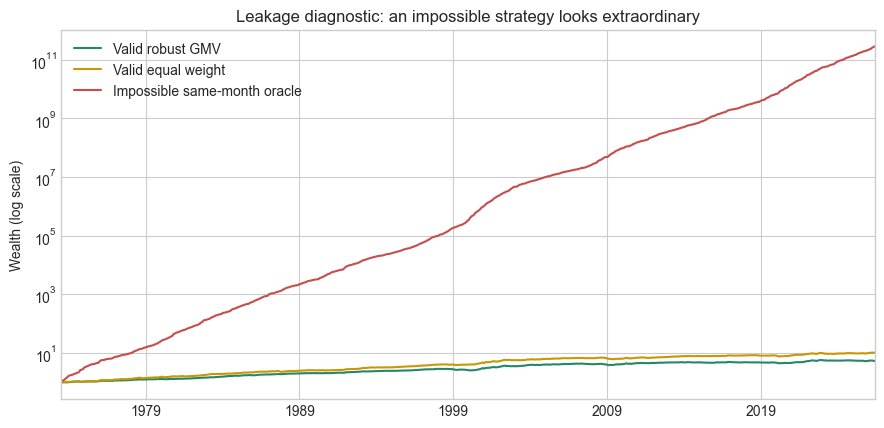

In [5]:
cost_rows = []
for bps in [0,5,10,25,50]:
    net = walk.gross_return - walk.turnover*bps*1e-4
    stats = performance_summary(net, periods_per_year=12)
    cost_rows.append({'cost_bps':bps, **stats})
cost_table = pd.DataFrame(cost_rows).set_index('cost_bps')
display(cost_table[['annualized_geometric_return','annualized_volatility','sharpe_ratio','max_drawdown']])

oracle = factors.loc[walk.index, FACTORS].max(axis=1)
audit = pd.DataFrame({
    'Valid robust GMV': walk.net_return,
    'Valid equal weight': equal,
    'Impossible same-month oracle': oracle
})
display(pd.DataFrame({c:performance_summary(audit[c], periods_per_year=12) for c in audit}).T)
ax=(1+audit).cumprod().plot(figsize=(10.5,4.8),logy=True,color=[GREEN,GOLD,RED])
ax.set(title='Leakage diagnostic: an impossible strategy looks extraordinary',ylabel='Wealth (log scale)',xlabel='')
plt.show()

## 6. Research conclusion and model-risk register

- Optimization converts covariance error into weight error through matrix inversion. Condition numbers and bootstrap weight distributions belong in the core report.
- Shrinkage and constraints reduce sampling dispersion but do not create information; they express a preference for stable portfolios.
- Equal weight is a serious benchmark. Complexity is justified only by out-of-sample outcomes robust to costs and design choices.
- An impossible oracle demonstrates how dramatically look-ahead bias can inflate results.

> **Boundary of the evidence.** The saved factor returns omit fund fees, financing limits, capacity, taxes, and factor-replication slippage. Historical covariance stability is assumed conditionally, not proven.

### Extensions

1. Select shrinkage intensity using nested cross-validation inside each training window.
2. Add turnover directly to the optimization objective and trace the efficient cost–risk frontier.
3. Compare iid bootstrap weights with block-bootstrap weights under serial dependence.
4. Form confidence sets for Sharpe-ratio differences rather than ranking point estimates.